In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from google.colab import drive
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_recall_fscore_support, classification_report
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
drive.mount('/content/drive')
titanic = pd.read_csv('/content/drive/MyDrive/dane/titanic.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Podzieliłem moją pracę na etapy, żeby trzymać się ścisłego planu i hopefully poprawnie wykonać zadanie z uwzględnieniem wniosków z poprzedniego zadania i nie doprowadzić do wycieku danych:
1. zamiana surowych kolumn na inne, lepsze
2. podział na train i test
3. utworzenie modelu dummy classifier (baseline) i trening na secie treningowym
4. utworzenie wlasciwego modelu np knn, tree, svm i wyodrebnienie najlepszych hiperparametrow za pomoca gridsearch i uzycie pipeline do czyszczenia brakow, kodowania, skalowania
5. najlepszy model robi predict test
6. wnioski



Zgodnie z wnioskami z poprzedniego zadania, przeprowadzam zmiany na poszczególnych kolumnach: ```Cabin``` na ```Has_cabin``` ponieważ braki stanowią aż ok 80% kolumny więc dzielimy to na ma kabinę i nie ma / nie wiadomo, porzucamy niepotrzebne kolumny które nie dają mi za dużo informacji przydatnych do trenowania modelu, oraz liczymy członków rodziny żeby jeszcze bardziej zredukować liczbe kolumn.

In [2]:
#1
titanic['Has_Cabin'] = titanic['Cabin'].notna().astype(int)
titanic = titanic.drop(columns=['Cabin'])

titanic = titanic.drop(columns=['Ticket', 'Name', 'PassengerId'])

titanic['FamilySize'] = titanic['SibSp'] + titanic['Parch'] + 1
titanic = titanic.drop(columns=['SibSp', 'Parch'])


In [3]:
#2 dzielimy wzgledem survived
X_train, X_test, y_train, y_test = train_test_split(titanic.drop(columns=['Survived']), titanic['Survived'], test_size=0.2, random_state=2137, stratify=titanic['Survived'])

In [4]:
#3
model = DummyClassifier(strategy='uniform')
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))
confusion_matrix(y_test, y_pred)

              precision    recall  f1-score   support

           0       0.53      0.42      0.47       110
           1       0.30      0.41      0.35        69

    accuracy                           0.41       179
   macro avg       0.42      0.41      0.41       179
weighted avg       0.44      0.41      0.42       179



array([[46, 64],
       [41, 28]])

Średnio 52% accuracy, co stanowi niską poprzeczkę dla naszego modelu. Przejdźmy teraz do wyboru tego najlepszego.

POTĘŻNY test modeli

In [5]:
#poprawka, robie pipeline bo dochodzi do wycieku danych podczas gridtestu
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder

class GroupMedianImputer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        self.medians_ = X.groupby('Pclass')['Fare'].median().to_dict()
        self.global_median_ = X['Fare'].median()
        return self
    def transform(self, X):
        X_out = X.copy()
        X_out['Fare'] = X_out['Fare'].fillna(X_out['Pclass'].map(self.medians_)).fillna(self.global_median_)
        return X_out[['Fare']]
class RandomAgeImputer(BaseEstimator, TransformerMixin):
    def __init__(self, seed=67):
        self.seed = seed
    def fit(self, X, y=None):
        self.train_ages_ = X['Age'].dropna().values
        return self
    def transform(self, X):
        np.random.seed(self.seed)
        X_out = X.copy()
        mask = X_out['Age'].isna()
        if mask.any():
            np.random.seed(self.seed)
            X_out.loc[mask, 'Age'] = np.random.choice(self.train_ages_, size=mask.sum())
        return X_out[['Age']]
fare_pipeline = Pipeline([
    ('imputer', GroupMedianImputer()),
    ('scaler', RobustScaler())
])
age_pipeline = Pipeline([
    ('imputer', RandomAgeImputer()),
    ('scaler', StandardScaler())
])
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
])
preprocessor = ColumnTransformer(transformers=[
    ('fare', fare_pipeline, ['Fare', 'Pclass']),
    ('family', RobustScaler(), ['FamilySize']),
    ('age', age_pipeline, ['Age']),
    ('cat', cat_pipeline, ['Embarked']),
    ('sex', OrdinalEncoder(categories=[['female', 'male']]), ['Sex'])
])

In [13]:
#4
models = [{
    'name': 'DecisionTree',
    'model': DecisionTreeClassifier(random_state=2137),
    'params': {
        'model__max_depth': [2, 3, 5, 10, None],
        'model__criterion': ['gini', 'entropy'],
        'model__min_samples_leaf': [1, 3, 5]}},
  {
    'name': 'k-NN',
    'model': KNeighborsClassifier(),
    'params': {
        'model__n_neighbors': [3, 5, 7, 11],
        'model__weights': ['uniform', 'distance']
    }
  },
  {
    'name': 'SVM',
    'model': SVC(random_state=2137),
    'params': {
        'model__C': [0.1, 1, 10],
        'model__kernel': ['rbf', 'linear']}
  }]
results = []
for m in models:
    pipeline = Pipeline([
        ('prep', preprocessor),
        ('model', m['model'])
    ])
    grid = GridSearchCV(
        estimator=pipeline,
        param_grid=m['params'],
        cv=5,
        scoring='accuracy'
    )
    grid.fit(X_train, y_train)
    results.append({
        'model': m['name'],
        'najlepszy wynik': grid.best_score_,
        'najlepsze hiperparametry': grid.best_params_,
        'najlepszy model': grid.best_estimator_
    })
results_df = pd.DataFrame(results).sort_values(by='najlepszy wynik', ascending=False)
display(results_df)

,model,najlepszy wynik,najlepsze hiperparametry,najlepszy model
0,DecisionTree,0.810460,"{'model__criterion': 'entropy', 'model__max_de...","(ColumnTransformer(transformers=[('fare',\n ..."
2,SVM,0.806244,"{'model__C': 1, 'model__kernel': 'rbf'}","(ColumnTransformer(transformers=[('fare',\n ..."
1,k-NN,0.779553,"{'model__n_neighbors': 11, 'model__weights': '...","(ColumnTransformer(transformers=[('fare',\n ..."


Walka na żyletki ale ostatecznie DecisionTree pokonuje SVM o długość nosa, zatem to on zostanie naszym modelem który podejmie się ostatecznego testu, natomiast DecisionTree potrzebował do tego maksymalnej możliwej głębi. Same wyniki prezentują się pozytywnie i znacznie przewyższają wyniki baseline. Zanim jednak przejdę do testowania zwycięzcy zwizualizuję zależność accuracy od hiperparametrów reszty uczestników.

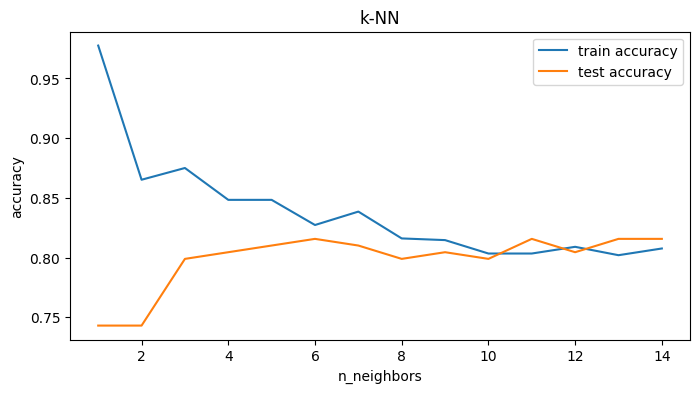

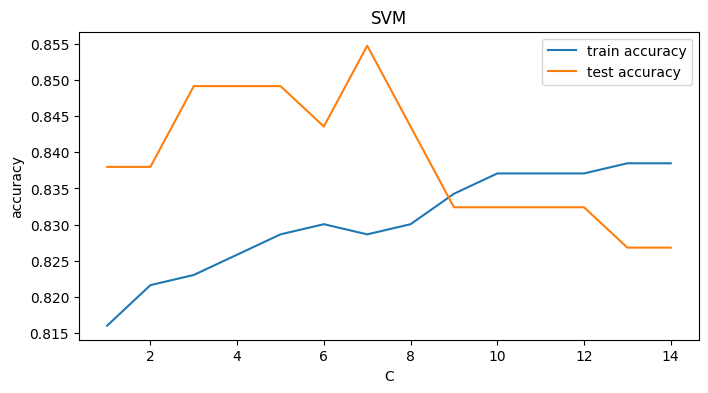

In [7]:
neighbors = range(1, 15)
train_acc, test_acc = [], []

for k in neighbors:
    knn_pipe = Pipeline([
        ('prep', preprocessor),
        ('knn', KNeighborsClassifier(n_neighbors=k, weights='uniform'))
    ])
    knn_pipe.fit(X_train, y_train)
    train_acc.append(accuracy_score(y_train, knn_pipe.predict(X_train)))
    test_acc.append(accuracy_score(y_test, knn_pipe.predict(X_test)))

plt.figure(figsize=(8, 4))
plt.title('k-NN')
plt.plot(neighbors, train_acc, label='train accuracy')
plt.plot(neighbors, test_acc, label='test accuracy')
plt.xlabel('n_neighbors')
plt.ylabel('accuracy')
plt.legend()
plt.show()

c_val = range(1,15)
train_acc, test_acc = [], []

for c in c_val:
    svm_pipe = Pipeline([
        ('prep', preprocessor),
        ('svm', SVC(C=c, kernel='rbf', random_state=2137))
    ])
    svm_pipe.fit(X_train, y_train)
    train_acc.append(accuracy_score(y_train, svm_pipe.predict(X_train)))
    test_acc.append(accuracy_score(y_test, svm_pipe.predict(X_test)))
plt.figure(figsize=(8, 4))
plt.title('SVM')
plt.plot(c_val, train_acc, label='train accuracy')
plt.plot(c_val, test_acc, label='test accuracy')
plt.xlabel('C')
plt.ylabel('accuracy')
plt.legend()
plt.show()


Na wykresach widać idealnie, że wysoki wynik podczas treningu ma się nijak do wyników na teście. k-NN: Ogromny spadek accuracy na treningu przy przejściu z jednego sąsiada na dwóch i dalszy spadek, ale podczas testu widać brak zmian. Z SVM z kolei sytuacja odwrotna, train accuracy rośnie, a test accuracy w tym samym czasie zalicza spadek. Niemniej jednak rozstrzał jest dosyć mały bo ok. 4% między maxem a minimum, w przeciwieństwie do k-NN gdzie ten rozstrzał na wykresie wynosi aż 20%, słaba stabilność modelu. Oczywiście miejmy z tyłu głowy, że powyższe wykresy treningowe nie są wynikiem kroswalidacji a pojedynczych treningów, ale chciałem je uwzględnić dla zobrazowania jak zmieniają się wyniki w zależności od jednego hiperparametru. Przejdźmy zatem do testu finałowego naszego zwycięzcy.

In [8]:
#5
winner = results_df.iloc[0]['najlepszy model']

y_pred_test = winner.predict(X_test)
y_pred_train = winner.predict(X_train)

print(classification_report(y_train, y_pred_train))
confusion_matrix(y_train, y_pred_train)
print(classification_report(y_test, y_pred_test))
confusion_matrix(y_test, y_pred_test)

              precision    recall  f1-score   support

           0       0.86      0.93      0.89       439
           1       0.86      0.75      0.80       273

    accuracy                           0.86       712
   macro avg       0.86      0.84      0.85       712
weighted avg       0.86      0.86      0.86       712

              precision    recall  f1-score   support

           0       0.83      0.89      0.86       110
           1       0.80      0.71      0.75        69

    accuracy                           0.82       179
   macro avg       0.82      0.80      0.81       179
weighted avg       0.82      0.82      0.82       179



array([[98, 12],
       [20, 49]])

#6
Jak widzimy naszemu modelowi udało się uzyskać 82% na secie testowym, jest to nieznacznie wyżej niż na gridsearch więc raczej nie doszło tutaj do przeuczenia, ale jest to aż o 3,5% mniej niż SVM. Naprawdę wysoki recall osób zmarłych, nie można tego samego powiedzieć o osobach, które przeżyły, gdzie ten wskaźnik jest duużo niższy. Model po prostu przeocza ludzi którzy mogli przeżyć. Wynika to najprawdopodobniej z faktu, że osób zmarłych było o wiele więcej niż ocalałych. Overall myślę, że poszło mu naprawdę dobrze, chociaż teraz wiedząc już jak się rozjeżdża recall, być może lepszą metryką niż accuracy w gridsearch byłby właśnie recall. Sprawdźmy teraz wyniki modelu gdy pozmieniamy trochę hiperparametry.

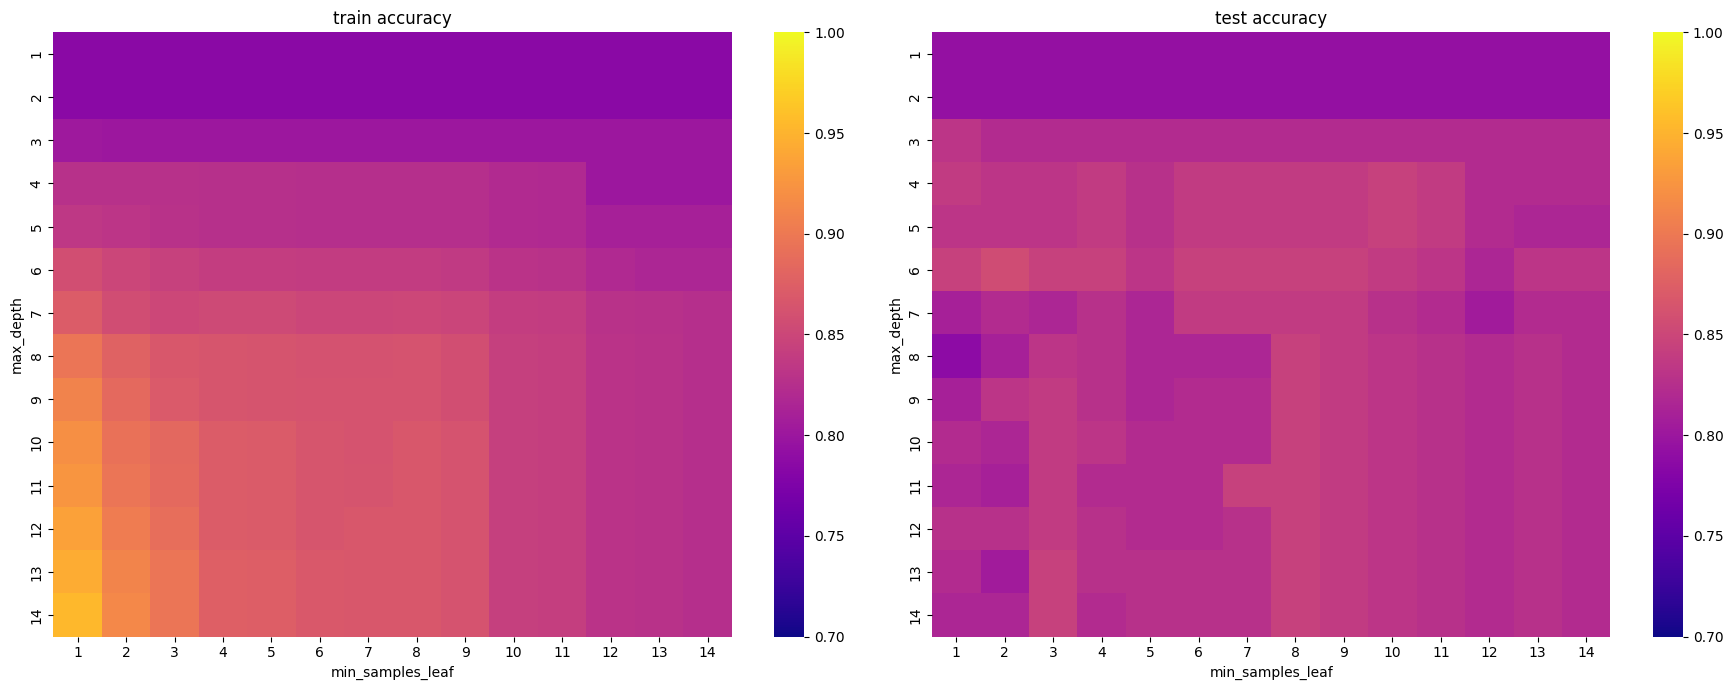

In [12]:
leafs = range(1, 15)
depths = range(1, 15)
train_scores = []
test_scores = []

results=[]
for d in depths:
    for l in leafs:
        tree_pipe = Pipeline([
            ('prep', preprocessor),
            ('tree', DecisionTreeClassifier(max_depth=d, min_samples_leaf=l, random_state=2137))
        ])
        tree_pipe.fit(X_train, y_train)
        results.append({
            'max_depth': d,
            'min_samples_leaf': l,
            'train_acc': accuracy_score(y_train, tree_pipe.predict(X_train)),
            'test_acc': accuracy_score(y_test, tree_pipe.predict(X_test))
        })
df_res = pd.DataFrame(results)
pivot_train = df_res.pivot(index='max_depth', columns='min_samples_leaf', values='train_acc')
pivot_test = df_res.pivot(index='max_depth', columns='min_samples_leaf', values='test_acc')

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
sns.heatmap(pivot_train, ax=axes[0], cmap='plasma', vmin=0.7, vmax=1.0)
axes[0].set_title('train accuracy', fontsize=12)
axes[0].set_xlabel('min_samples_leaf')
axes[0].set_ylabel('max_depth')

sns.heatmap(pivot_test, ax=axes[1], cmap='plasma', vmin=0.7, vmax=1.0)
axes[1].set_title('test accuracy', fontsize=12)
axes[1].set_xlabel('min_samples_leaf')
axes[1].set_ylabel('max_depth')
plt.tight_layout()
plt.show()



Heatmapa train accuracy ładnie nam obrazuje, że model ulega przeuczeniu i po prostu uczy się na pamięć rozwiązań i uzyskuje niemalże 100% accuracy dla skrajnych hiperparametrów. Natomiast test accuracy pozwala nam wyodrębnić jaskrawe punkty, z których możemy wyciągnąć te hiperparametry, dla których accuracy było najlepsze, np. widzimy, że dla ```min_samples_leaf=8``` i ```max_depth od 7 do 14``` accuracy jest zauważalnie wyższe niż dla sąsiednich kolumn. Widać również zwycięski wynik z gridsearch czyli ```max_depth=10``` oraz ```min_samples_leaf=5``` który poradził sobie gorzej niż powiedzmy 10:3 albo 10:8